# To-dos (13/11/23)

1. Remove fits to log, only use fit_short
2. Investigate the bad fits for the slices 
3. Confirm that the mcmc really does work for the entire fit
4. Plot the curve using [a, b, c, d] and play around with these values
5. Fix d = 0.5, and add "error parameters" for the temperature (eT + f) 
6. Run mcmc for this starting from e = 1, f = 0
7. Just use the entire series as your fit function

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import data_analysis_script as da
import importlib as im
from scipy.optimize import curve_fit, minimize
import emcee as mc #try markov chain monte carlo

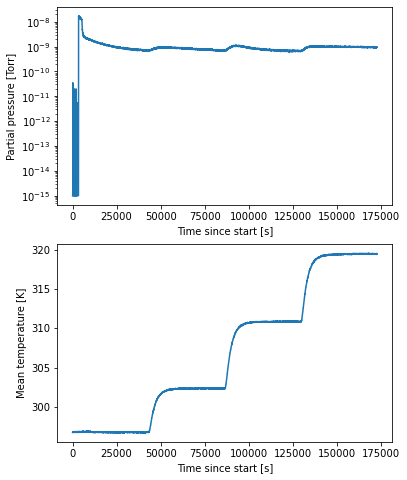

In [2]:
from data_analysis_script import Dataset
run_label = '2024-02-01' ## Change this to look at different runs
d = Dataset(run_label=run_label, gases=['O2'], data_path='20240201/') #Insert data_path='xxxxxx/'
d.GetData()
d.PlotSingleGas('O2')

In [3]:
time = np.array(d.data['O2']['Exposure_time'])
temp = np.array(d.data['O2']['Mean_temp']) #['Mean_temp'])
p = np.array(d.data['O2']['Partial_pressure'])

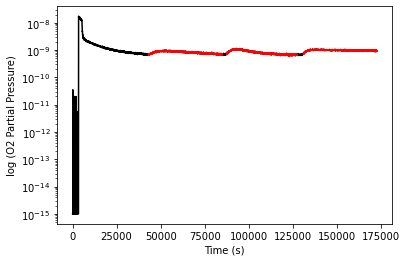

In [4]:
time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

plt.semilogy(time, p, 'k') # Plot the logarithm (base 10) of the partial pressure of O2 (oxygen) against time. 
plt.ylabel('log (O2 Partial Pressure)') 
plt.xlabel('Time (s)')

for ts in time_slices:
    gpts = (time > ts[0]) & (time < ts[1])
    plt.semilogy(time[gpts], p[gpts],'r')
# plt.ylim(2e-9, 3e-8)
#plt.xlim(12e4, 14e4)
plt.show()

# Fit to fitfunction (no log, no short)

In [21]:
def plot_single(x,y,bp, log=False):
    plt.figure(figsize=(5,5))
    plt.subplot(2,1,1)
    plt.plot(x[0,:],y,'k')
    if(log):
        plt.plot(x[0,:], d.logfitfunction(x, *bp), 'r')
    else:
        plt.plot(x[0,:], d.fitfunction(x, *bp), 'r')
    plt.ylabel('Pressure [mbar]')
    plt.xlabel("Time [s]")

    # to plot the temperature 
#     plt.subplot(2,1,2)
#     plt.plot(x[0,:],x[1,:],'k')
#     plt.ylabel('Temperature [K]')
#     plt.xlabel("Time [s]")
        
    plt.show()

## fit each time individually
im.reload(da)

time_slices = [[44000, 85000],
               [87500, 127500],
               [131000, 175000]]

fit_params = np.zeros((len(time_slices), 3))

for j, ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])

    tT = np.vstack((time[gpts]-time[gpts][0], temp[gpts]))
    y = p[gpts]
    
    spars = [4.48859880e-04, 3.45969798e+03, 3.98032858e-01]
    bp, bc = curve_fit(d.fitfunction, tT, y, p0=spars)

    print(bp)
    #bp = spars
    fit_params[j,:] = bp

    plot_single(tT, y, bp)

# To visually see how the parameters change from slice to slice   

#     plt.figure()
#     plt.subplot(3,1,1)
#     plt.semilogy([1,2,3], fit_params[:,0], 'ko-')
#     plt.ylabel("A")

#     plt.subplot(3,1,2)
#     plt.semilogy([1,2,3], fit_params[:,1], 'bo-')
#     plt.ylabel("B")

#     plt.subplot(3,1,3)
#     plt.semilogy([1,2,3], fit_params[:,2], 'ro-')
#     plt.ylabel("C")
#     plt.xlabel("Time period")
#     plt.gca().set_xticks([1,2,3])
#     plt.subplots_adjust(hspace=0)
print(fit_params)
plt.show()

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 800.

# fit to log.fitfunction

      fun: 22.98820596292592
 hess_inv: array([[1.51439806e+01, 1.47901133e+01, 4.69624062e+03, 1.62094127e-03],
       [1.47901133e+01, 1.44452526e+01, 4.58660429e+03, 1.58314742e-03],
       [4.69624062e+03, 4.58660429e+03, 1.45638080e+06, 5.02619888e-01],
       [1.62094127e-03, 1.58314742e-03, 5.02619888e-01, 1.73662706e-07]])
      jac: array([ 1.62453413e-01,  1.90446615e-01, -9.13381577e-04, -5.45511161e+02])
  message: 'Desired error not necessarily achieved due to precision loss.'
     nfev: 1062
      nit: 131
     njev: 210
   status: 2
  success: False
        x: array([-1.79635870e+01, -1.78381167e+01,  8.83522823e+02,  1.04928719e-04])


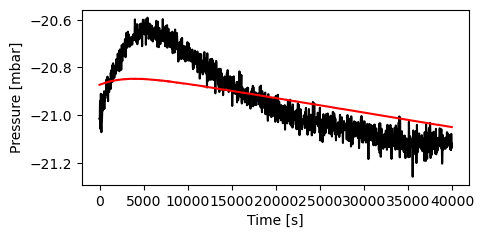

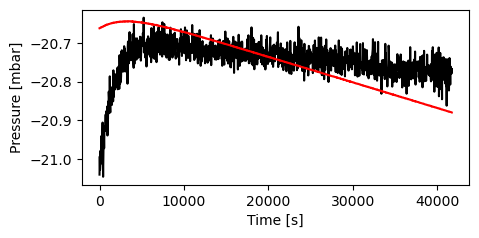

In [22]:
# Define the function to calculate the combined chi-squared value by 
# evaluating the goodness of fit for multiple datasets simultaneously
def combined_chisq(params, data_dict):
    # Number of datasets
    ndsets = len(data_dict.keys())

    # Separate the parameters: amplitude for each dataset and common parameters b and c.
    amp_vec = params[:ndsets]  # Amplitude parameters, unique for each dataset.
    b, c = params[-2], params[-1]  # Common parameters for all datasets.

    tot_chisq = 0  # Initialize the total chi-squared value.

    # Iterate over each dataset to calculate its chi-squared value.
    for n in range(ndsets):
        cdat = data_dict[n]  # Current dataset.
        # Calculate the chi-squared value for the current dataset.
        curr_chisq = np.sum((d.logfitfunction(cdat[0], amp_vec[n], b, c) - np.log(cdat[1]))**2)
        # Check for NaN values and handle them by adding infinity to the total chi-squared.
        if not np.isnan(curr_chisq):
            tot_chisq += curr_chisq
        else:
            tot_chisq += np.inf

    return tot_chisq  # Return the total chi-squared value.

# Define time slices for the analysis.
time_slices = [#[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

# Dictionary to store data for each time slice.
combined_data = {}

# Prepare the data for each time slice and store in the dictionary.
for j, ts in enumerate(time_slices):
    # Get the data points within the current time slice.
    gpts = (time > ts[0]) & (time < ts[1])
    # Stack the time and temperature data for the current time slice.
    tT = np.vstack((time[gpts]-time[gpts][0], temp[gpts]))
    # Get the corresponding pressure data.
    y = p[gpts]
    # Store the data in the dictionary.
    combined_data[j] = [tT, y]

# Initial parameters for the optimization.
spars = [-7.74881756e+00, -8.04881756e+00, 3.44741784e+03, 3.82129198e-01]

# Perform the optimization to minimize the combined chi-squared value.
res = minimize(combined_chisq, spars, args=(combined_data))

# Extract the best-fit parameters.
bp = res.x
print(res)  # Print the result of the optimization.

# Plot the fitted model for each time slice.
for j in range(len(time_slices)):
    # Plot the data and the fitted model for the current time slice.
    plot_single(combined_data[j][0], np.log(combined_data[j][1]), [bp[j], bp[-2], bp[-1]], log=True)

# MCMC

In [23]:
## try MCMC
import emcee as mc


 57%|█████▋    | 57/100 [00:00<00:00, 286.81it/s]/home/rjt45/.conda/envs/new_env/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: overflow encountered in square
  app.launch_new_instance()
/home/rjt45/.conda/envs/new_env/lib/python3.7/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in double_scalars
  lnpdiff = f + nlp - state.log_prob[j]
/home/rjt45/.conda/envs/new_env/lib/python3.7/site-packages/numpy/core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/gpfs/gibbs/project/david_moore/rjt45/outgassing-setup/analysis/data_analysis_script.py:39: RuntimeWarning: overflow encountered in exp
  return a - b/tT[1] - c*tT[0]*np.exp(-b/tT[1])
/gpfs/gibbs/project/david_moore/rjt45/outgassing-setup/analysis/data_analysis_script.py:39: RuntimeWarning: invalid value encountered in multiply
  return a - b/tT[1] - c*tT[0]*np.exp(-b/tT[1])
100%|██████████| 100/100 [00

Converged values: [-1.08539998e+00  1.70368969e+02  6.84005784e+06 -1.70687485e+03
  1.72181595e+01]


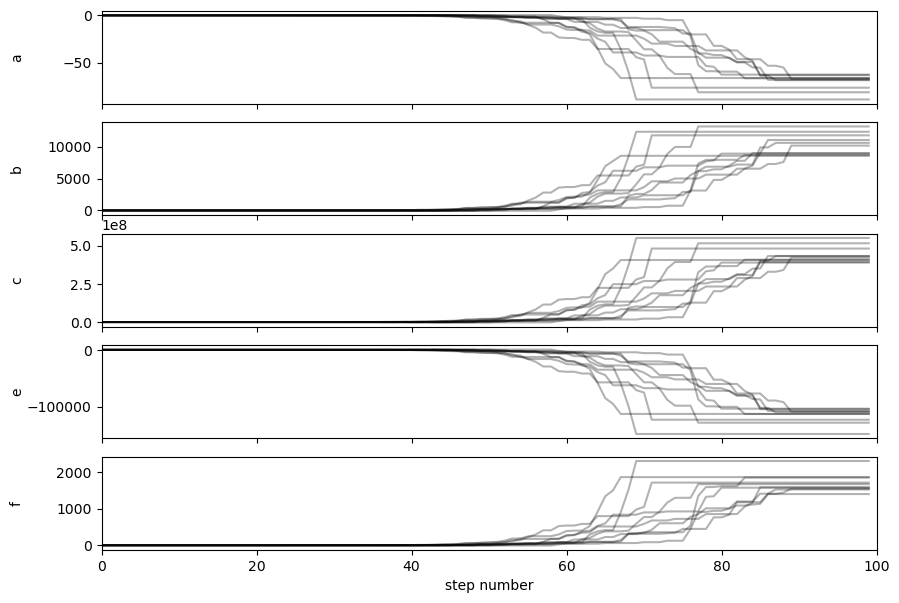

In [24]:
ndim = 5
nwalkers = 10
nsteps = 100
initial_parameters = np.array([5e-4, 4.48859880e-01, 3.98032858e+03, 1, 0.1])
pos = [initial_parameters * (1 + 0.01*np.random.randn(ndim)) for _ in range(nwalkers)]
sampler = mc.EnsembleSampler(nwalkers, ndim, combined_chisq, args=(combined_data,))
sampler.run_mcmc(pos, nsteps, progress=True)
'''samples = sampler.chain[:, 50:, :].reshape((-1, ndim))
optimized_params = np.median(samples, axis=0)
print(optimized_params)'''

samples = sampler.chain

# Flatten the chain so that we have a list of samples for each walker
flattened_samples = sampler.chain.reshape((-1, ndim))

# Print the converged values (e.g., medians of the distributions)
converged_values = np.median(flattened_samples, axis=0)
print('Converged values:', converged_values)

fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b", "c", "e", "f"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");


In [25]:
spars = np.array([3.03352926e-10, 1.12386982e+06, -3.44588211e+04, 1])
pos = spars * (1 + 0.1*np.random.randn(8, 4))
nwalkers, ndim = pos.shape

sampler = mc.EnsembleSampler(nwalkers, ndim, combined_chisq, args=(combined_data,))
sampler.run_mcmc(pos, 500, progress=True)

  0%|          | 0/500 [00:00<?, ?it/s]/home/rjt45/.conda/envs/new_env/lib/python3.7/site-packages/ipykernel_launcher.py:17: RuntimeWarning: overflow encountered in square
  app.launch_new_instance()
  5%|▍         | 23/500 [00:00<00:02, 224.70it/s]/gpfs/gibbs/project/david_moore/rjt45/outgassing-setup/analysis/data_analysis_script.py:39: RuntimeWarning: overflow encountered in multiply
  return a - b/tT[1] - c*tT[0]*np.exp(-b/tT[1])
100%|██████████| 500/500 [00:01<00:00, 409.74it/s]


State([[ 5.42554500e-09  1.47021101e+07 -1.05832816e+05 -1.78441789e+01]
 [ 2.68662225e-09  1.13674433e+07 -1.10291849e+05 -6.03595795e+00]
 [ 1.33908761e-09  1.25614191e+07 -1.40506367e+05  9.63056191e-01]
 [-4.13662729e-10  7.23322524e+06 -1.09602286e+05  7.17127070e+00]
 [ 5.74846188e-10  8.35926400e+06 -1.08564424e+05  2.90376561e+00]
 [ 9.70398537e-10  9.49940252e+06 -1.13733605e+05  1.36057462e+00]
 [-1.28041038e-09  5.72849118e+06 -1.07916776e+05  1.07292780e+01]
 [ 1.34535757e-09  8.72130158e+06 -1.07843963e+05  3.23903182e-01]], log_prob=[inf inf inf inf inf inf inf inf], blobs=None, random_state=('MT19937', array([3419552563, 2136933399, 3422451601,  280442904, 1403748232,
       3736727043, 2238822298, 1532946787, 1248944518, 2925398547,
       2901399886, 2996163213, 1949353806, 2657802052,  844961544,
       3870099618, 2659624649,  153735697,  404888640, 2933922969,
       1384827078,  493819198, 2249781576,  643306474,  289006066,
       3304983451, 1093684015, 354645525

In [26]:
print(pos.shape)

(8, 4)


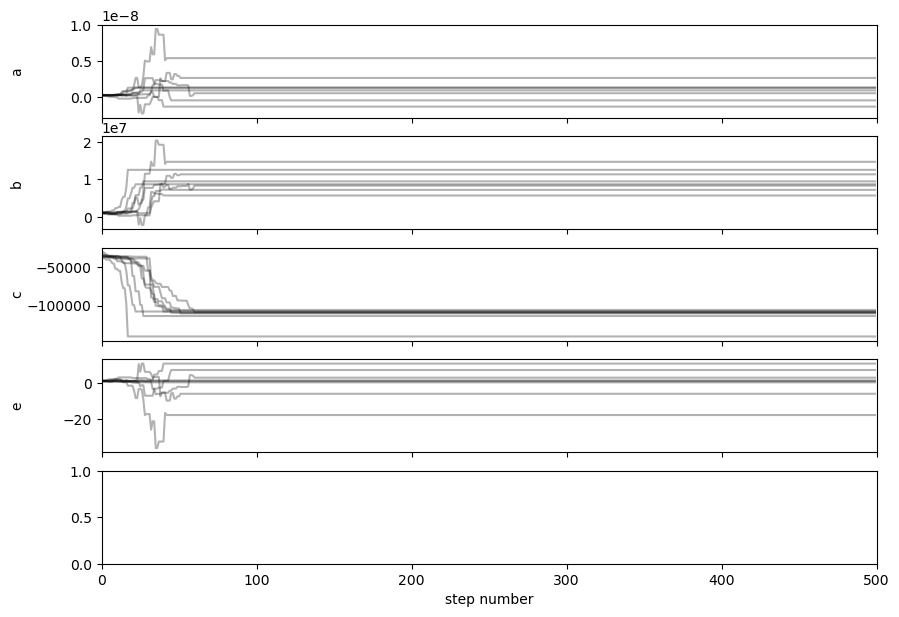

In [27]:
fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b", "c", "e", "f"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [22]:
## now try in the short time limit

def plot_single_short(x,y, bp, log=False):
    #print('y: ', y)
    plt.figure(figsize=(8,8))
    plt.subplot(2,1,1)
    plt.plot(x[0,:],y,'k')
    if(log):
        plt.plot(x[0,:], d.logfitfunction(x, *bp), 'r')
    else:
        plt.plot(x[0,:], d.fitfunction_short_temp_offset(x, *bp), 'r')
    plt.ylabel('Pressure [mbar]')
    plt.xlabel("Time [s]")
    plt.show()
    
def combined_chisq_short(params, data_dict):
    
    ndsets = len(data_dict.keys())
 
    a, b, c, e, f = params[0], params[1], params[2], params[3], params[4]
    

    tot_chisq = 0
    sig = 0.5e-9 ## error on values

    for n in range(ndsets):
        cdat = data_dict[n]
        curr_chisq = np.sum(((d.fitfunction_short_temp_offset(cdat[0], a, b, c, e, f) - cdat[1])/sig)**2)
        if(not np.isnan(curr_chisq)):
            tot_chisq += curr_chisq
        else:
            tot_chisq += np.inf

    return tot_chisq

In [28]:
## fit each time individually
im.reload(da)
time_slices = [[44000, 85000],
               [87500, 127500],
               [131000, 175000]]

fit_params = np.zeros((len(time_slices), 5))

for j, ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])

    tT = np.vstack((time[gpts], temp[gpts]))
    y = p[gpts]
    
    spars = [3.03352926e-8, 1.12386982e+06, -3.44588211e+04, 1, 0]
    #res = minimize(combined_chisq, spars, args=(combined_data))
    #print('res:',res)  # Print the result of the optimization.

# Plot the fitted model for each time slice.
#for j in range(len(time_slices)):
    # Plot the data and the fitted model for the current time slice.
   # plot_single(combined_data[j][0], np.log(combined_data[j][1]), [bp[j], bp[-2], bp[-1]], log=True)
    
    bp, bc = curve_fit(d.fitfunction_short_temp_offset, tT, y, p0=spars, method='lm', maxfev=90000)
   
    print('bp: ',bp)
    #spars = bp
    #bp = spars

    plot_single_short(tT, y, bp)
    
    

(2, 1342)
(2, 1342)
(2, 1342)
(2, 1342)
(2, 1342)
(2, 1342)
(2, 1342)
(2, 1342)
bp:  [ 3.03352926e-08  1.12386982e+06 -3.44588211e+04  1.00000000e+00
  0.00000000e+00]


/home/rjt45/.conda/envs/new_env/lib/python3.7/site-packages/scipy/optimize/minpack.py:834: OptimizeWarning: Covariance of the parameters could not be estimated
  category=OptimizeWarning)


NameError: name 'plot_single_short' is not defined

In [29]:
def combined_chisq_short(params, data_list):
    ds = Dataset("","")
    ndsets = len(data_list)

    a, b, c, e, f = params[0], params[1], params[2], params[3], params[4]


    tot_chisq = 0
    sig = 0.5e-9 ## error on values
    e_err = 0.2
    f_err = 1
    
    

    for n in range(ndsets):
        cdat = data_list[n]
        curr_chisq = np.sum(((d.fitfunction_short_temp_offset(cdat, a, b, c, e, f) - cdat[1])/sig)**2)+ ((e - 1)/(2*e_err))**2 + ((f - 0)/(2*f_err))**2
        if(not np.isnan(curr_chisq)):
            tot_chisq += curr_chisq
        else:
            tot_chisq += np.inf

    return tot_chisq

TypeError: __init__() missing 1 required positional argument: 'data_path'

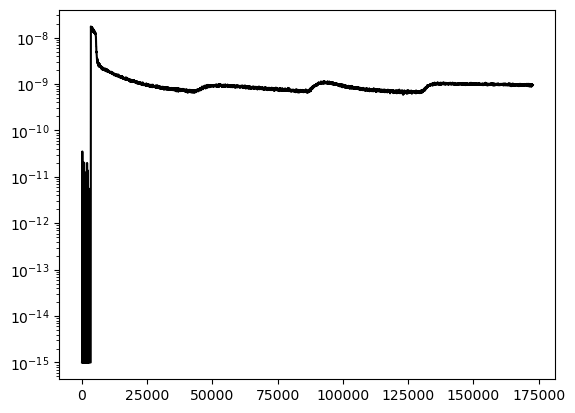

In [30]:
## now try to fit all together

time_slices = [[43000, 85000],
               [87500, 127500],
               [131000, 175000]]

plt.figure()
plt.semilogy(time, p, 'k')

for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT = np.vstack((time[gpts], temp[gpts]))
    y = p[gpts]
    spars = [3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0]
    #Spars that work for curvefit: 3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0
    #Spars from old teflon data: 3.48859880e-09, 3.45969798e+03, 3.98032858e-01, 1, 0
    res = minimize(combined_chisq_short, spars, args=(combined_data), method='Nelder-Mead')
    bp = res.x
    #bp, bc = curve_fit(d.fitfunction_short_temp_offset, tT, y, p0=spars, method='lm', maxfev=90000)
    plt.plot(tT[0], d.fitfunction_short_temp_offset(tT,*bp),'r')
    print('bp:', bp)
    #res = minimize(combined_chisq_short, spars, args=(combined_data,))
    #bp = res.x


tT = []
y = []
combined_data = []
plt.figure()
plt.semilogy(time, p, 'k')
for j,ts in enumerate(time_slices):
    gpts = (time > ts[0]) & (time < ts[1])
    tT.append((np.vstack((time[gpts], temp[gpts]))))
    y.append(p[gpts])
    combined_data.append([time[gpts], p[gpts]])
spars = [3.48859880e-09, -3.45969798e+01, 3.98032858e-01, 1, 0]
#bp, bc = curve_fit(d.fitfunction_short_temp_offset, np.vstack((time,temp)), p, p0=spars, method='lm', maxfev=90000)
res = minimize(combined_chisq_short, spars, args=(combined_data), method='Nelder-Mead')
bp = res.x

for j in range(len(time_slices)):
    tvals = combined_data[j][0]
    plt.plot(tvals, d.fitfunction_short_temp_offset(tT[j], *bp), 'r')

print('bp:', bp)

plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")


In [31]:
print(len(combined_data[2][0]))
print(combined_data[0][0])

KeyError: 2

In [32]:
print(tT[0])

[43019. 43050. 43080. ... 84916. 84947. 84977.]


In [33]:
print(tvals.shape)

NameError: name 'tvals' is not defined

In [34]:
print(tT.shape)

(2, 1374)


In [35]:
print(len(time_slices))

3


In [36]:
print(ts)

[43000, 85000]


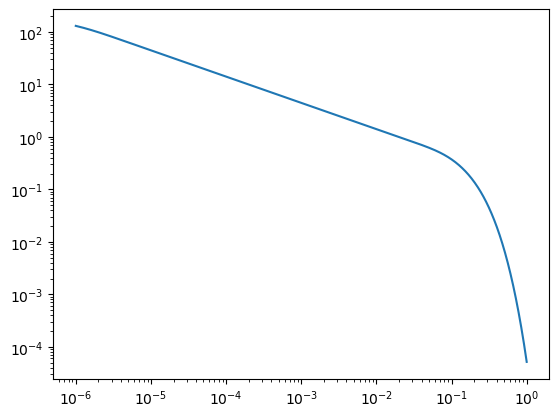

In [28]:
tvec = np.logspace(-6,0,1000)

maxn = 200

fval = np.zeros_like(tvec)
for n in range(maxn):
    fval += np.exp(-(np.pi*(2*n+1))**2*tvec)

plt.figure()
plt.loglog(tvec, fval)

In [29]:
pos = bp[4] * (1 + 1e-3*np.random.randn(16, len(spars)))
nwalkers, ndim = pos.shape

ffn = lambda p,d: -combined_chisq_short(p,d)

sampler = mc.EnsembleSampler(nwalkers, ndim, ffn, args=(combined_data,))
sampler.run_mcmc(pos, 5000, progress=True)

ValueError: Initial state has a large condition number. Make sure that your walkers are linearly independent for the best performance

In [ ]:
fig, axes = plt.subplots(5, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["a", "b", "c", "e","f"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)

axes[-1].set_xlabel("step number");

In [ ]:
import corner

flat_samples = sampler.get_chain(discard=1000, thin=15, flat=True)
print(flat_samples.shape)

fig = corner.corner(flat_samples, labels=labels)

In [ ]:
plt.figure()
plt.semilogy(time, p, 'k')

inds = np.random.randint(len(flat_samples), size=10)
for ind in inds:
    sample = flat_samples[ind]
    for j in range(len(time_slices)):
        tvals = combined_data[j][0][0]
        plt.plot(tvals, d.fitfunction_short_temp_offset(combined_data[j][0], sample[0], sample[1], sample[2], sample[3], sample[4]), 'r', alpha=0.5)

# plt.ylim(4.5e-9, 6e-9)
plt.ylabel('Pressure [mbar]')
plt.xlabel("Time [s]")

In [ ]:
from IPython.display import display, Math

CI = 10 ## L/s
Area = 0.01 ## m^2
mbar_to_Pa = 100
K = 0.22
p_atm = 1.01e5 #Pa
m_to_cm = 100
L_to_m3 = 1e-3

mcmc_D0 = np.percentile((flat_samples[:, 0]*CI*mbar_to_Pa*L_to_m3/(K*p_atm*Area) * m_to_cm)**2, [16, 50, 84])
mcmc_Ea = np.percentile(flat_samples[:, 1], [16, 50, 84])

print("D0 [cm^2/s]: ", mcmc_D0)
print("Activation energy [K]: ", mcmc_Ea)